# <center><font color='green'>Desafío - Introducción al Machine Learning</font></center>

## Parte I:

#### 1. ¿Cuál es la diferencia entre el aprendizaje supervisado y el aprendizaje no supervisado?
La principal diferencia es que en el aprendizaje supervisado se utilizan datos que ya tienen una respuesta o etiqueta conocida. El modelo aprende a partir de esos datos para poder hacer predicciones en el futuro.
En cambio, en el aprendizaje no supervisado los datos no tienen etiquetas, por lo que el modelo intenta encontrar patrones o grupos dentro de la información por sí solo.

#### 2. En la industria de la salud, a menudo se utiliza el machine learning para predecir la probabilidad de enfermedades o condiciones médicas en función de diferentes variables de entrada, como síntomas, antecedentes médicos y factores de estilo de vida. Imagina que tienes un conjunto de datos que contiene información de pacientes y su diagnóstico (enfermo/no enfermo). ¿Qué tipo de aprendizaje utilizarías para construir un modelo predictivo?

Utilizaría aprendizaje supervisado, específicamente un modelo de clasificación.
Esto se debe a que los datos ya tienen un resultado conocido (enfermo o no enfermo). El modelo puede aprender de esa información para luego predecir si un nuevo paciente tiene o no la enfermedad según sus síntomas, antecedentes médicos y estilo de vida.

#### 3. ¿Por qué se divide el dataset en dos conjuntos en el aprendizaje supervisado?
El dataset se divide para poder evaluar qué tan bien funciona el modelo con datos que no ha visto antes.
Los dos conjuntos son:
- Conjunto de entrenamiento (training set):
Se utiliza para entrenar el modelo, es decir, para que el algoritmo aprenda las relaciones entre los datos.
- Conjunto de prueba (test set):
Se utiliza para evaluar el modelo, verificando si puede hacer buenas predicciones con datos nuevos.
Esto ayuda a evitar que el modelo solo memorice los datos y asegura que funcione bien en situaciones reales.

#### 4. Diferencia entre regresión lineal en enfoque estadístico y en machine learning
La principal diferencia es el objetivo del análisis.
- En el enfoque estadístico, la regresión lineal se usa principalmente para entender la relación entre las variables y analizar cómo influye cada una.
- En el enfoque de machine learning, el objetivo principal es hacer predicciones lo más precisas posible, aunque no siempre se enfoque tanto en interpretar cada variable.

#### 5. Escoge una industria de acuerdo a su área de interés, rubro de trabajo o área de estudios (por ejemplo, salud, telecomunicaciones, retail, medioambiente, etc). Menciona al menos 1 aplicación en esa industria de: a. Aprendizaje Supervisado (Clasificación) b. Aprendizaje Supervisado (Regresión) c. Aprendizaje No Supervisado (Clustering) d. Aprendizaje No Supervisado (Reducción de dimensionalidad)

#### Industria elegida: banca
 - a. Aprendizaje Supervisado (Clasificación):
Un ejemplo es la detección de fraude en transacciones. El modelo clasifica las operaciones como fraudulentas o normales según diferentes características de la transacción.
 - b. Aprendizaje Supervisado (Regresión):
Se puede usar para predecir el riesgo crediticio de un cliente, es decir, estimar la probabilidad de que una persona no pague un préstamo.
 - c. Aprendizaje No Supervisado (Clustering):
Se utiliza para segmentar a los clientes del banco según sus hábitos financieros, ingresos o uso de productos bancarios.
 - d. Aprendizaje No Supervisado (Reducción de dimensionalidad):
Se usa para reducir la cantidad de variables en grandes bases de datos, lo que ayuda a simplificar el análisis y mejorar el rendimiento de los modelos.

## Parte II:

#### 6. Carga los datos de la base data_housing.csv e importa las librerías necesarias para cargar los datos en un DataFrame, manipularlos, hacer cálculos, analizarlos y construir modelos de regresión lineal. Utiliza Pandas, NumPy y Scikit-learn.

In [23]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos el dataframe usando 'pd.read_csv()'.
df= pd.read_csv('data-housing.csv',delimiter=';')

# Mostramos el dataframe creado.
df

,price,area,bedrooms,bathrooms,stories,guestroom,hotwaterheating,airconditioning,parking
0,13300000,7420,4,2,3,no,no,yes,2
1,12250000,8960,4,4,4,no,no,yes,3
2,12250000,9960,3,2,2,no,no,no,2
3,12215000,7500,4,2,2,no,no,yes,3
4,11410000,7420,4,1,2,yes,no,yes,2
...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,no,no,no,2
541,1767150,2400,3,1,1,no,no,no,0
542,1750000,3620,2,1,1,no,no,no,0
543,1750000,2910,3,1,1,no,no,no,0


#### 7. Genera un informe de calidad de datos de la base. Analiza la existencia de datos atípicos, extraños o nulos. Además, analiza las posibles correlaciones entre las variables.

In [24]:
# Definimos la función informe de calidad del dataframe.
def informe_calidad(df):
    print("=== INFORME DE CALIDAD DE DATOS ===\n")
    
    # 1. Valores Nulos.
    print("1. Análisis de Nulos:")
    nulos = df.isnull().sum()
    print(nulos)
    print(f"\nTotal de nulos en el dataset: {nulos.sum()}")
    
    # 2. Filas Duplicadas.
    print("\n" + "-"*30)
    print("2. Análisis de Duplicados:")
    duplicados = df.duplicated().sum()
    print(f"Se encontraron {duplicados} filas duplicadas.")
    
    # 3. Valores Atípicos (Outliers).
    print("\n" + "-"*30)
    print("3. Detección de Outliers (Numéricos):")
    df_num = df.select_dtypes(include=[np.number])
    
    for col in df_num.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        
        cant_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
        print(f" - Columna '{col}': {cant_outliers} outliers detectados.")

    # Gráfico para visualizar los outliers del precio.
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='price', color='orange')
    plt.title("Visualización de Outliers en el Precio")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

=== INFORME DE CALIDAD DE DATOS ===

1. Análisis de Nulos:
price              0
area               0
bedrooms           0
bathrooms          0
stories            0
guestroom          0
hotwaterheating    0
airconditioning    0
parking            0
dtype: int64

Total de nulos en el dataset: 0

------------------------------
2. Análisis de Duplicados:
Se encontraron 0 filas duplicadas.

------------------------------
3. Detección de Outliers (Numéricos):
 - Columna 'price': 15 outliers detectados.
 - Columna 'area': 12 outliers detectados.
 - Columna 'bedrooms': 12 outliers detectados.
 - Columna 'bathrooms': 1 outliers detectados.
 - Columna 'stories': 41 outliers detectados.
 - Columna 'parking': 12 outliers detectados.


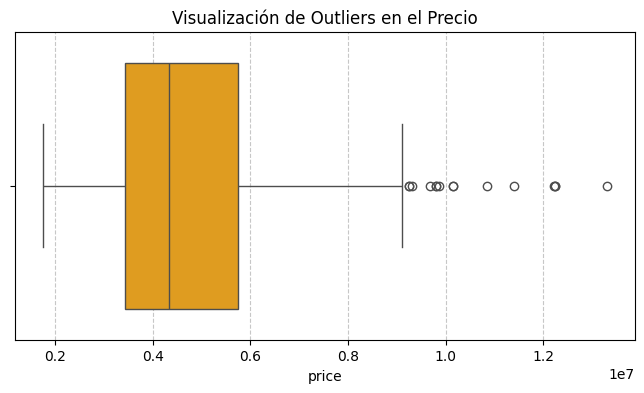

In [25]:
# Ejecutamos la función definida anteriormente para mostrar el informe.
informe_calidad(df)

Del informe de calidad de datos se observa que el dataset no presenta valores nulos ni duplicados. Sin embargo, se identifican valores atípicos en algunas variables numéricas, los cuales pueden afectar el análisis de correlación, por lo que serán eliminados. 
Además, algunas variables de tipo texto como guestroom, hotwaterheating y airconditioning podrían influir en el precio, por lo que deberán transformarse a formato numérico para incluirlas en el análisis.

In [26]:
# Definimos la función para limpiar los valores atípicos.
def limpiar_outliers(df, columnas):
    df_limpio = df.copy()
    
    for col in columnas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Filtramos el dataframe: nos quedamos solo con lo que está dentro de los límites.
        antes = df_limpio.shape[0]
        df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]
        despues = df_limpio.shape[0]
        
        print(f"Columna '{col}': Se eliminaron {antes - despues} outliers.")
    
    return df_limpio

In [27]:
# Se procederá a aplicar una función para eliminar los valores atípicos en columnas de área y precio antes de realizar el análisis de correlación,
# ya que presentan una cantidad significativa de outliers y además son variables clave en el análisis del precio de la vivienda.
columnas_a_limpiar = ['price', 'area']
df = limpiar_outliers(df, columnas_a_limpiar)

Columna 'price': Se eliminaron 15 outliers.
Columna 'area': Se eliminaron 13 outliers.


In [29]:
# Mapeo de variables categóricas.

# Definimos el diccionario de mapeo.
mapping = {'yes': 1, 'no': 0}

# Aplicamos el mapeo a las columnas correspondientes.
columnas_a_convertir = ['guestroom', 'hotwaterheating', 'airconditioning']

for col in columnas_a_convertir:
    df[col] = df[col].map(mapping)

# Verificamos los cambios.
df.head()

,price,area,bedrooms,bathrooms,stories,guestroom,hotwaterheating,airconditioning,parking
15,9100000,6000,4,1,2,0,0,0,2
16,9100000,6600,4,2,2,1,0,1,1
17,8960000,8500,3,2,4,0,0,1,2
18,8890000,4600,3,2,2,1,0,1,2
19,8855000,6420,3,2,2,0,0,1,1


correlación con el Precio:
price              1.000000
area               0.533186
airconditioning    0.471706
bathrooms          0.466483
stories            0.446839
bedrooms           0.335328
parking            0.321058
guestroom          0.303994
hotwaterheating    0.075979
Name: price, dtype: float64


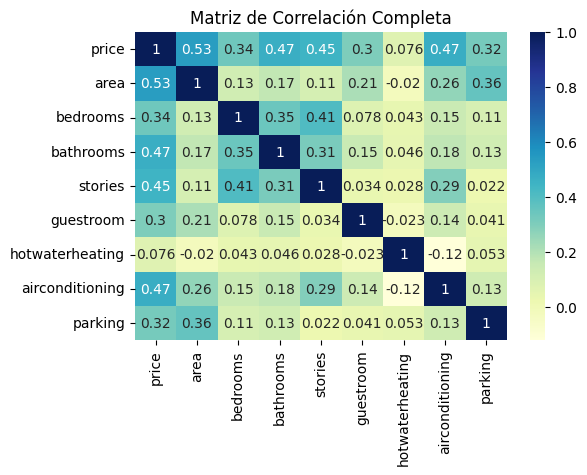

In [31]:
# Calculamos matriz de correlación.
corr=df.corr()

# Visualizamos la relación de todo con el precio.
print("correlación con el Precio:")
print(corr['price'].sort_values(ascending=False))

# Un pequeño gráfico para ver las relaciones.
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Matriz de Correlación Completa")
plt.show()

#### Conclusión: 
Después de transformar las variables de texto a formato numérico, se analizó la correlación entre las variables y el precio de la vivienda.
- Los resultados muestran que el área (0.53) es la variable con mayor correlación con el precio, lo que indica que las viviendas con mayor tamaño tienden a tener precios más altos. También se observa una correlación importante con aire acondicionado (0.47), cantidad de baños (0.46) y número de pisos (0.44), lo que sugiere que estas características influyen de manera considerable en el valor de la propiedad.
- Por último, hotwaterheating (0.07) presenta una correlación muy baja, lo que indica que en este conjunto de datos esta característica no parece tener un impacto significativo en el precio de la vivienda.

#### 8.Genera un modelo de regresión lineal. Para ello:
- a. Importa el estimador de regresión lineal de Scikit-learn.
- b. Divide los datos (80% train y 20% test)
- c. Crea una instancia del modelo de regresión lineal.
- d. Ajusta el modelo utilizando los datos de entrenamiento.

In [40]:
# Importamos el estimador de regresión lineal.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
# Dividimos los datos (80% entrenamiento / 20% prueba).
# Primero separamos variables independientes (X) y variable objetivo (y).
X = df.drop('price', axis=1)   # variables predictoras
y = df['price']                # variable objetivo

In [37]:
# Ahora dividimos los datos:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [38]:
# Creamos una instancia del modelo.
modelo = LinearRegression()

In [39]:
# Ajustamos el modelo con los datos de entrenamiento.
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 9. Evalúa el modelo. Para ello:
- a. Utiliza los datos de entrenamiento y calcula métricas de evaluación, como el error cuadrado medio (MSE) o el coeficiente de determinación (R^2). Grafica los coeficientes.
- b. Utiliza los datos de prueba para realizar predicciones con el modelo entrenado, y evalúa el rendimiento del modelo comparando las predicciones con los valores reales.

In [41]:
# Realizamos las predicciones sobre el set de entrenamiento.
y_train_pred = modelo.predict(X_train)

In [42]:
# Calculamos métricas.
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("MSE entrenamiento:", mse_train)
print("R2 entrenamiento:", r2_train)

MSE entrenamiento: 960409582069.32
R2 entrenamiento: 0.6179733364406715


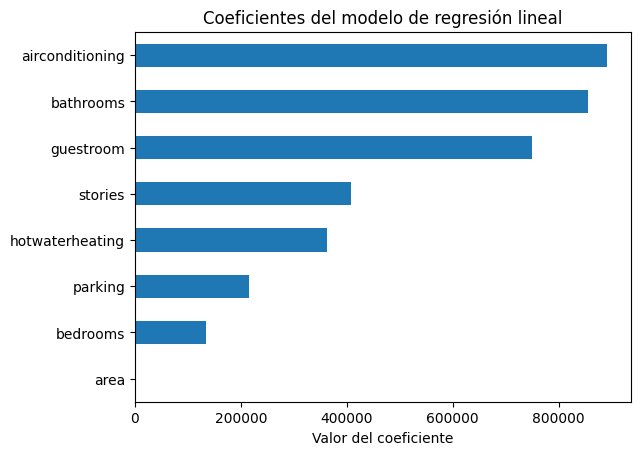

In [43]:
# Graficamos los coeficientes.
coeficientes = pd.Series(modelo.coef_, index=X.columns)

coeficientes.sort_values().plot(kind='barh')
plt.title("Coeficientes del modelo de regresión lineal")
plt.xlabel("Valor del coeficiente")
plt.show()

In [44]:
# Evaluación con los datos de prueba. Ahora evaluamos el modelo con datos que no vio durante el entrenamiento.
y_test_pred = modelo.predict(X_test)

In [45]:
# Evaluamos rendimiento en Test.
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MSE test:", mse_test)
print("R2 test:", r2_test)

MSE test: 1153287991423.5747
R2 test: 0.5618213216802054


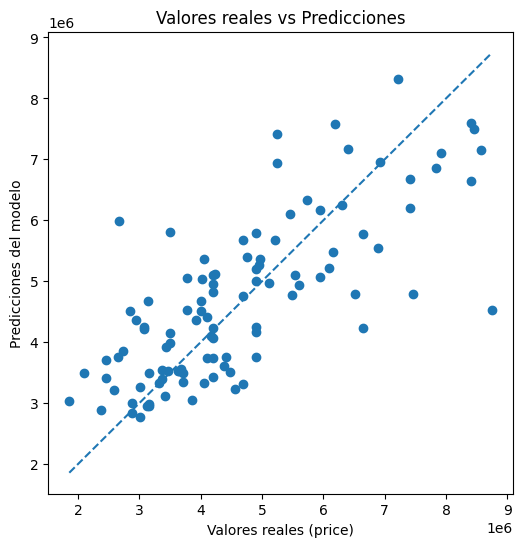

In [46]:
# Gráfico de comparación: Real vs Predicho.
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Valores reales (price)")
plt.ylabel("Predicciones del modelo")
plt.title("Valores reales vs Predicciones")

plt.show()

#### Conclusión: 
Luego de entrenar el modelo de regresión lineal, se evaluó su rendimiento utilizando las métricas MSE y R² tanto en el conjunto de entrenamiento como en el conjunto de prueba.
El modelo obtuvo un R² de 0.61 en entrenamiento y 0.56 en test, lo que indica que es capaz de explicar aproximadamente entre el 56% y el 61% de la variabilidad del precio de las viviendas a partir de las variables incluidas en el modelo. La diferencia entre ambos valores no es muy grande, lo que sugiere que el modelo generaliza de manera aceptable y no presenta un sobreajuste significativo.
El gráfico de valores reales vs predicciones muestra que muchas observaciones se ubican cerca de la línea diagonal, lo que indica que el modelo logra aproximar razonablemente los precios reales, aunque todavía existe cierta dispersión en algunos puntos, especialmente en viviendas con precios más altos.
Por otro lado, el gráfico de coeficientes del modelo permite observar la influencia de cada variable en la predicción del precio. Sin embargo, es importante considerar que las variables del modelo están medidas en diferentes escalas. Por ejemplo, la variable area se mide en metros cuadrados, mientras que otras variables como airconditioning o guestroom son variables binarias (0 o 1).
Debido a estas diferencias de escala, los coeficientes no son completamente comparables entre sí, ya que una variable con valores más grandes o en otra unidad de medida puede aparecer con un coeficiente menor. Por esta razón, aunque el gráfico muestra que variables como airconditioning y bathrooms tienen coeficientes altos, el área de la vivienda sigue siendo una de las variables más importantes, como se observó previamente en el análisis de correlación.
En general, el modelo logra capturar parte importante de la relación entre las características de las viviendas y su precio, aunque todavía existe margen de mejora.